# Do High Electricity Price States Sit on Undeveloped Geothermal Energy Potential?

## Research Question
Do states with high residential electricity prices have significant unused Enhanced Geothermal Systems (EGS) potential?

## Hypothesis
States with high electricity prices have significant unused geothermal potential that could provide cost-competitive clean energy.

## Datasets
- **DOE U.S. Geothermal Supply Curves (2024):** Point-level EGS resource estimates at 4,500m, 5,500m, and 6,500m depth. Source: GDR OpenEI
- **EIA Annual Electricity Price by State:** Average retail residential prices in cents/kWh by state (2019). Source: EIA

## Data Cleaning and Exploration

In [26]:
import pandas as pd

eia_raw = pd.read_csv('/home/ap4825/climatedatascience/avgprice_annual.csv', header=1)
print(eia_raw.shape)
print(eia_raw.head())

(4605, 9)
   Year State Industry Sector Category  Residential Commercial  Industrial  \
0  2020    AK  Total Electric Industry        22.57      19.58       15.88   
1  2020    AL  Total Electric Industry        12.58      11.55        5.87   
2  2020    AR  Total Electric Industry        10.41       8.61        5.89   
3  2020    AZ  Total Electric Industry        12.27      10.11        6.07   
4  2020    CA  Total Electric Industry        20.45      17.53       14.27   

   Transportation  Other  Total  
0            0.00    NaN  19.82  
1            0.00    NaN   9.84  
2           13.32    NaN   8.32  
3            9.38    NaN  10.44  
4           10.07    NaN  18.00  


In [2]:
print(eia_raw['Year'].unique())
print(eia_raw['Industry Sector Category'].unique())
print(eia_raw['State'].unique())

[2020 2019 2018 2017 2016 2015 2014 2013 2012 2011 2010 2009 2008 2007
 2006 2005 2004 2003 2002 2001 2000 1999 1998 1997 1996 1995 1994 1993
 1992 1991 1990]
['Total Electric Industry' 'Full-Service Providers'
 'Restructured Retail Service Providers' 'Energy-Only Providers'
 'Delivery-Only Service']
['AK' 'AL' 'AR' 'AZ' 'CA' 'CO' 'CT' 'DC' 'DE' 'FL' 'GA' 'HI' 'IA' 'ID'
 'IL' 'IN' 'KS' 'KY' 'LA' 'MA' 'MD' 'ME' 'MI' 'MN' 'MO' 'MS' 'MT' 'NC'
 'ND' 'NE' 'NH' 'NJ' 'NM' 'NV' 'NY' 'OH' 'OK' 'OR' 'PA' 'RI' 'SC' 'SD'
 'TN' 'TX' 'UT' 'VA' 'VT' 'WA' 'WI' 'WV' 'WY' 'US']


For this analysis, I want to use 2019 as it is pre-COVID. I also want to filter the data to make sure only states are included. 


In [3]:
eia = eia_raw[
    (eia_raw['Year'] == 2019) &
    (eia_raw['Industry Sector Category'] == 'Total Electric Industry') &
    (eia_raw['State'] != 'DC') &
    (eia_raw['State'] != 'US')
     ]

print(eia.shape)
print(eia.head())

(50, 9)
     Year State Industry Sector Category  Residential Commercial  Industrial  \
167  2019    AK  Total Electric Industry        22.92      19.80       16.94   
168  2019    AL  Total Electric Industry        12.53      11.52        5.95   
169  2019    AR  Total Electric Industry         9.80       8.78        6.13   
170  2019    AZ  Total Electric Industry        12.43      10.25        6.28   
171  2019    CA  Total Electric Industry        19.15      16.67       13.40   

     Transportation  Other  Total  
167            0.00    NaN  20.22  
168            0.00    NaN   9.83  
169           11.73    NaN   8.22  
170            9.68    NaN  10.52  
171            8.91    NaN  16.89  


Intital analysis will look at residential electricity first. 

In [4]:
eia = eia[['State', 'Residential']]
print(eia.head())
print(eia.dtypes)

    State  Residential
167    AK        22.92
168    AL        12.53
169    AR         9.80
170    AZ        12.43
171    CA        19.15
State           object
Residential    float64
dtype: object


In [5]:
geo_4500 = pd.read_csv('/home/ap4825/climatedatascience/egs_4500m_supply-curve.csv')
print(geo_4500.shape)
print(geo_4500.columns.tolist())
print(geo_4500.head())

(23905, 16)
['latitude', 'longitude', 'country', 'state', 'county', 'timezone', 'sc_point_gid', 'area_developable_sq_km', 'capacity_ac_mw', 'capacity_factor_ac', 'lcot_usd_per_mwh', 'lcoe_all_in_usd_per_mwh', 'cost_reinforcement_usd_per_mw', 'dist_reinforcement_km', 'dist_spur_km', 'cost_total_trans_usd_per_mw']
    latitude   longitude        country       state   county  timezone  \
0  48.981529 -122.209285  United States  Washington  Whatcom        -8   
1  48.887329 -122.163916  United States  Washington  Whatcom        -8   
2  48.913930 -122.003921  United States  Washington  Whatcom        -8   
3  48.793133 -122.118699  United States  Washington  Whatcom        -8   
4  48.819684 -121.958953  United States  Washington  Whatcom        -8   

   sc_point_gid  area_developable_sq_km  capacity_ac_mw  capacity_factor_ac  \
0           799               23.606829       64.726494            0.993177   
1          1179               26.003367       69.249927            0.993087   
2   

In [6]:
geo_5500 = pd.read_csv('/home/ap4825/climatedatascience/egs_5500m_supply-curve.csv')
geo_6500 = pd.read_csv('/home/ap4825/climatedatascience/egs_6500m_supply-curve.csv')

print('4500m median LCOE:', geo_4500['lcoe_all_in_usd_per_mwh'].median())
print('5500m median LCOE:', geo_5500['lcoe_all_in_usd_per_mwh'].median())
print('6500m median LCOE:', geo_6500['lcoe_all_in_usd_per_mwh'].median())


4500m median LCOE: 69.13291
5500m median LCOE: 70.5567
6500m median LCOE: 51.15058


In [7]:
print(geo_6500.shape)
print(geo_6500['state'].nunique())
print(geo_6500['state'].unique())

(17751, 16)
26
['Washington' 'Idaho' 'Montana' nan 'North Dakota' 'Oregon' 'South Dakota'
 'New Hampshire' 'Wyoming' 'California' 'Nevada' 'Nebraska' 'Pennsylvania'
 'Utah' 'Colorado' 'West Virginia' 'Maryland' 'Virginia' 'Arizona'
 'New Mexico' 'Texas' 'Oklahoma' 'Arkansas' 'Mississippi' 'Louisiana'
 'Alabama' 'Florida']


In [8]:
print(eia['State'].head())
print(geo_6500['state'].head())


167    AK
168    AL
169    AR
170    AZ
171    CA
Name: State, dtype: object
0    Washington
1    Washington
2    Washington
3    Washington
4    Washington
Name: state, dtype: object


In [9]:
state_to_abbr = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
    'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID',
    'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS',
    'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
    'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK',
    'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT',
    'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV',
    'Wisconsin': 'WI', 'Wyoming': 'WY'
}


geo_6500['state_abbr'] = geo_6500['state'].map(state_to_abbr)
print(geo_6500[['state', 'state_abbr']].head())

        state state_abbr
0  Washington         WA
1  Washington         WA
2  Washington         WA
3  Washington         WA
4  Washington         WA


In [10]:
geo_state = geo_6500.groupby('state_abbr').agg(
    total_capacity_mw=('capacity_ac_mw', 'sum'),
    median_lcoe=('lcoe_all_in_usd_per_mwh', 'median')
).reset_index()

print(geo_state.head())

  state_abbr  total_capacity_mw  median_lcoe
0         AL         784.267263    55.064625
1         AR       58609.129007    52.783932
2         AZ      345551.126760    46.241096
3         CA      328700.497547    57.483055
4         CO      428314.191081    51.282380


In [11]:
state_geo_elec = pd.merge(eia, geo_state, left_on='State', right_on='state_abbr', how='left')

In [12]:
state_geo_elec['residential_usd_mwh'] = state_geo_elec['Residential'] * 10

In [13]:
state_geo_elec ['residential_usd_mwh'] = state_geo_elec ['Residential'] * 10
print(state_geo_elec [['State', 'residential_usd_mwh', 'median_lcoe']].head(10))

  State  residential_usd_mwh  median_lcoe
0    AK                229.2          NaN
1    AL                125.3    55.064625
2    AR                 98.0    52.783932
3    AZ                124.3    46.241096
4    CA                191.5    57.483055
5    CO                121.8    51.282380
6    CT                218.7          NaN
7    DE                125.5          NaN
8    FL                117.0    57.832798
9    GA                117.6          NaN


In [14]:
print(state_geo_elec[['State', 'residential_usd_mwh', 'median_lcoe']].sort_values('residential_usd_mwh', ascending=False).to_string())

   State  residential_usd_mwh  median_lcoe
10    HI                320.6          NaN
0     AK                229.2          NaN
18    MA                219.2          NaN
6     CT                218.7          NaN
38    RI                217.3          NaN
29    NH                200.5    72.394356
4     CA                191.5    57.483055
33    NY                179.4          NaN
20    ME                178.9          NaN
45    VT                177.1          NaN
30    NJ                158.5          NaN
21    MI                157.4          NaN
47    WI                141.8          NaN
37    PA                138.0    66.374475
19    MD                131.2    70.488305
22    MN                130.4          NaN
13    IL                130.3          NaN
39    SC                129.9          NaN
15    KS                127.1          NaN
14    IN                125.8          NaN
7     DE                125.5          NaN
1     AL                125.3    55.064625
31    NM   

In [15]:
centroids = geo_6500.groupby('state_abbr').agg(
    lat=('latitude', 'mean'),
    lon=('longitude', 'mean')
).reset_index()

print(centroids.head())

  state_abbr        lat         lon
0         AL  30.764189  -88.346455
1         AR  33.505158  -92.501827
2         AZ  34.042801 -111.822635
3         CA  36.760259 -119.048772
4         CO  39.091945 -105.630399


In [16]:
state_geo_elec = pd.merge(state_geo_elec, centroids, left_on='State', right_on='state_abbr', how='left')
print(state_geo_elec.head())

  State  Residential state_abbr_x  total_capacity_mw  median_lcoe  \
0    AK        22.92          NaN                NaN          NaN   
1    AL        12.53           AL         784.267263    55.064625   
2    AR         9.80           AR       58609.129007    52.783932   
3    AZ        12.43           AZ      345551.126760    46.241096   
4    CA        19.15           CA      328700.497547    57.483055   

   residential_usd_mwh state_abbr_y        lat         lon  
0                229.2          NaN        NaN         NaN  
1                125.3           AL  30.764189  -88.346455  
2                 98.0           AR  33.505158  -92.501827  
3                124.3           AZ  34.042801 -111.822635  
4                191.5           CA  36.760259 -119.048772  


In [17]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

ERROR 1: PROJ: proj_create_from_database: Open of /opt/sw/anaconda3/2023.09/envs/pangeo23/share/proj failed


## Figure 1: Residential Electricity Prices by State
I decided to filter to 2019, as it was the last pre-COVID year in the data set. Then, plotted the top 15 states by residential price. New England and Pacific states dominate, paying nearly double the national average.

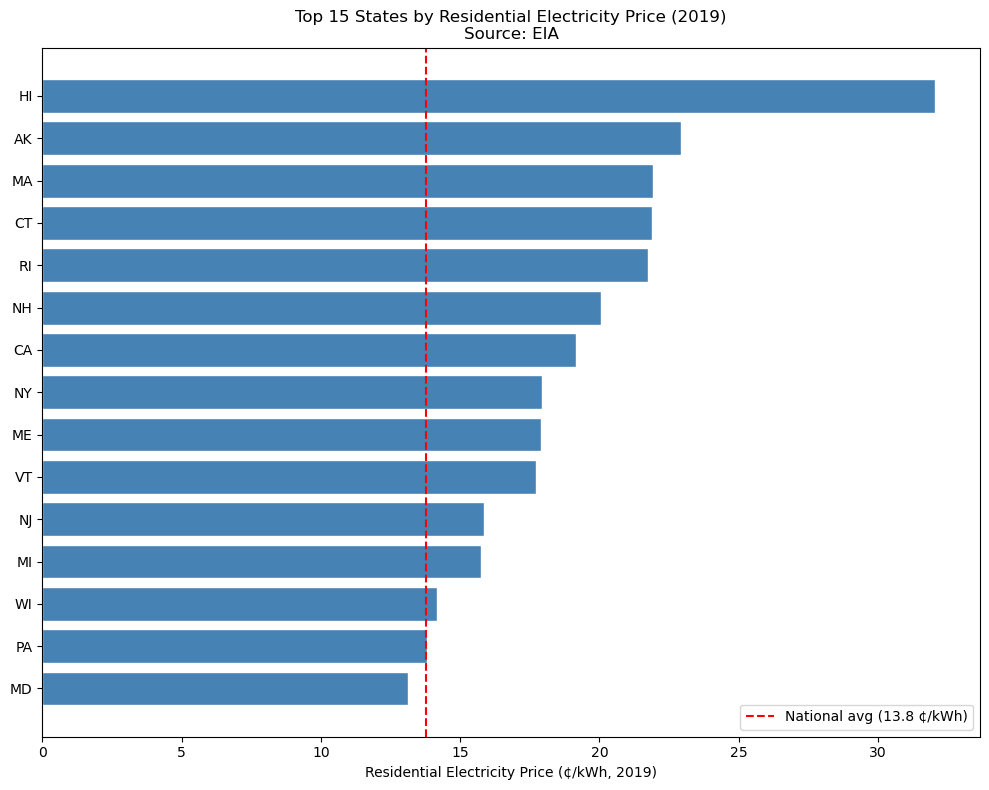

In [18]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 8))

top15 = eia.sort_values('Residential', ascending=True).tail(15)

ax.barh(top15['State'], top15['Residential'], color='steelblue', edgecolor='white')
ax.axvline(eia['Residential'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'National avg ({eia["Residential"].mean():.1f} ¢/kWh)')
ax.set_xlabel('Residential Electricity Price (¢/kWh, 2019)')
ax.set_title('Top 15 States by Residential Electricity Price (2019)\nSource: EIA')
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
state_centroids = {
    'AK': (64.2, -153.4), 'AL': (32.8, -86.8), 'AR': (34.9, -92.4), 'AZ': (34.3, -111.1),
    'CA': (37.2, -119.7), 'CO': (39.0, -105.5), 'CT': (41.6, -72.7), 'DE': (39.0, -75.5),
    'FL': (28.1, -81.6), 'GA': (32.7, -83.4), 'HI': (20.3, -156.4), 'IA': (42.1, -93.5),
    'ID': (44.4, -114.6), 'IL': (40.0, -89.2), 'IN': (39.9, -86.3), 'KS': (38.5, -98.4),
    'KY': (37.5, -85.3), 'LA': (31.1, -91.9), 'MA': (42.2, -71.5), 'MD': (39.1, -76.8),
    'ME': (45.4, -69.2), 'MI': (44.3, -85.4), 'MN': (46.4, -93.1), 'MO': (38.5, -92.5),
    'MS': (32.7, -89.7), 'MT': (47.0, -110.5), 'NC': (35.6, -79.4), 'ND': (47.5, -100.5),
    'NE': (41.5, -99.9), 'NH': (43.7, -71.6), 'NJ': (40.1, -74.5), 'NM': (34.4, -106.1),
    'NV': (39.3, -116.6), 'NY': (42.9, -75.5), 'OH': (40.4, -82.8), 'OK': (35.6, -97.5),
    'OR': (43.9, -120.6), 'PA': (41.2, -77.2), 'RI': (41.7, -71.5), 'SC': (33.9, -80.9),
    'SD': (44.4, -100.2), 'TN': (35.8, -86.3), 'TX': (31.1, -97.6), 'UT': (39.3, -111.1),
    'VA': (37.5, -79.4), 'VT': (44.1, -72.7), 'WA': (47.4, -120.5), 'WI': (44.6, -89.9),
    'WV': (38.6, -80.6), 'WY': (43.0, -107.6)
}

state_geo_elec['lat'] = state_geo_elec['State'].map(lambda s: state_centroids[s][0] if s in state_centroids else None)
state_geo_elec['lon'] = state_geo_elec['State'].map(lambda s: state_centroids[s][1] if s in state_centroids else None)

print(state_geo_elec[['State', 'lat', 'lon']].head(10))

  State   lat    lon
0    AK  64.2 -153.4
1    AL  32.8  -86.8
2    AR  34.9  -92.4
3    AZ  34.3 -111.1
4    CA  37.2 -119.7
5    CO  39.0 -105.5
6    CT  41.6  -72.7
7    DE  39.0  -75.5
8    FL  28.1  -81.6
9    GA  32.7  -83.4


## Figure 2: Geographic Distribution of Electricity Prices
The price map confirms the regional pattern: high prices cluster in the Northeast and Hawaii, while the South and West (besides California) pay less.

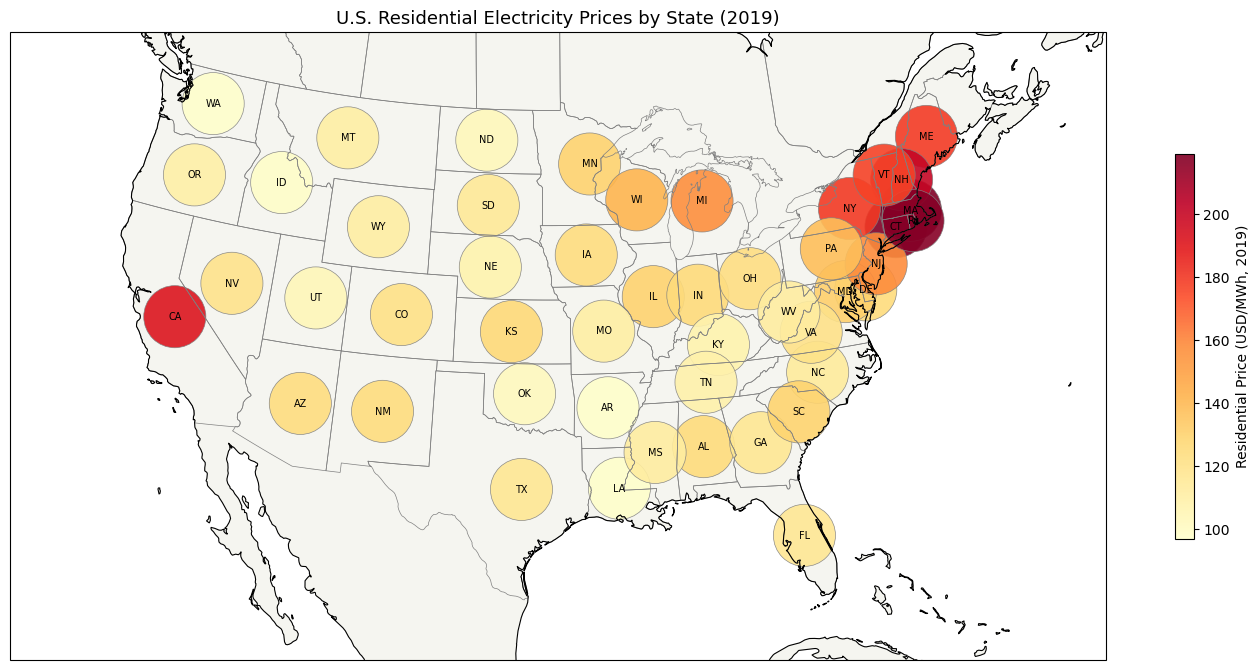

In [20]:
conus = state_geo_elec[~state_geo_elec['State'].isin(['AK', 'HI'])]

fig, ax = plt.subplots(figsize=(14, 8),
                       subplot_kw={'projection': ccrs.AlbersEqualArea(central_longitude=-96, central_latitude=37.5)})
ax.set_extent([-125, -66, 23, 50], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='#f5f5f0')

sc = ax.scatter(conus['lon'], conus['lat'],
                c=conus['residential_usd_mwh'],
                cmap='YlOrRd', s=2000, alpha=0.9,
                transform=ccrs.PlateCarree(), edgecolors='gray', linewidths=0.5)

for _, row in conus.dropna(subset=['lat']).iterrows():
    ax.text(row['lon'], row['lat'], row['State'], fontsize=7,
            ha='center', va='center', transform=ccrs.PlateCarree())

plt.colorbar(sc, ax=ax, label='Residential Price (USD/MWh, 2019)', shrink=0.5)
ax.set_title('U.S. Residential Electricity Prices by State (2019)', fontsize=13)
plt.tight_layout()
plt.show()

In [21]:
print(state_geo_elec['total_capacity_mw'].describe())


count        26.000000
mean     224848.703371
std      257859.901310
min          14.178934
25%       16883.693642
50%       93735.850695
75%      377782.365893
max      931372.757537
Name: total_capacity_mw, dtype: float64


In [22]:
import numpy as np
state_geo_elec['log_capacity'] = np.log10(state_geo_elec['total_capacity_mw'])
print(state_geo_elec['log_capacity'].describe())

count    26.000000
mean      4.540922
std       1.397955
min       1.151644
25%       4.187199
50%       4.964786
75%       5.576693
max       5.969124
Name: log_capacity, dtype: float64


## Figure 3: Geographic Distribution of EGS Geothermal Potential
The EGS Geothermal Potential dataset had data for three different depth tiers: 4,500 , 5,500 and 6,500. I used the 6,500m depth tier because it yields the lowest median LCOE. Only 26 states have modeled EGS resources. Potential is concentrated in the West and Great Plains.

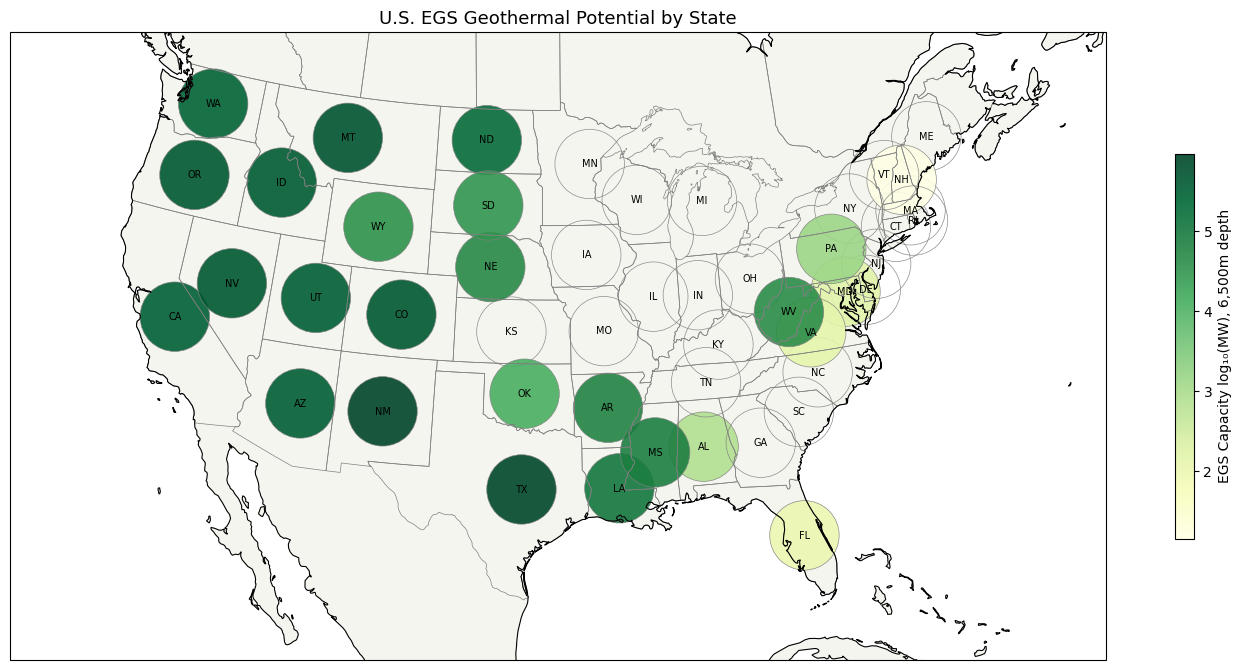

In [23]:
conus = state_geo_elec[~state_geo_elec['State'].isin(['AK', 'HI'])]
fig, ax = plt.subplots(figsize=(14, 8),
                       subplot_kw={'projection': ccrs.AlbersEqualArea(central_longitude=-96, central_latitude=37.5)})
ax.set_extent([-125, -66, 23, 50], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='#f5f5f0')

ax.legend
sc = ax.scatter(conus['lon'], conus['lat'],
                c=conus['log_capacity'],
                cmap='YlGn', s=2500, alpha=0.9,
                transform=ccrs.PlateCarree(), edgecolors='gray', linewidths=0.5)

for _, row in conus.dropna(subset=['lat']).iterrows():
    ax.text(row['lon'], row['lat'], row['State'], fontsize=7,
            ha='center', va='center', transform=ccrs.PlateCarree())

plt.colorbar(sc, ax=ax, label='EGS Capacity log₁₀(MW), 6,500m depth', shrink=0.5)
ax.set_title('U.S. EGS Geothermal Potential by State', fontsize=13)
plt.tight_layout()
plt.show()

## Figure 4: LCOE vs. Electricity Price
To assess economic viability, we compare each state's median EGS LCOE to its residential electricity price (both in USD/MWh). States below the dashed line have geothermal resources that are already cost-competitive. It is important to note that LCOE only represents the electricity generation costs not the transmission and distribution costs. 

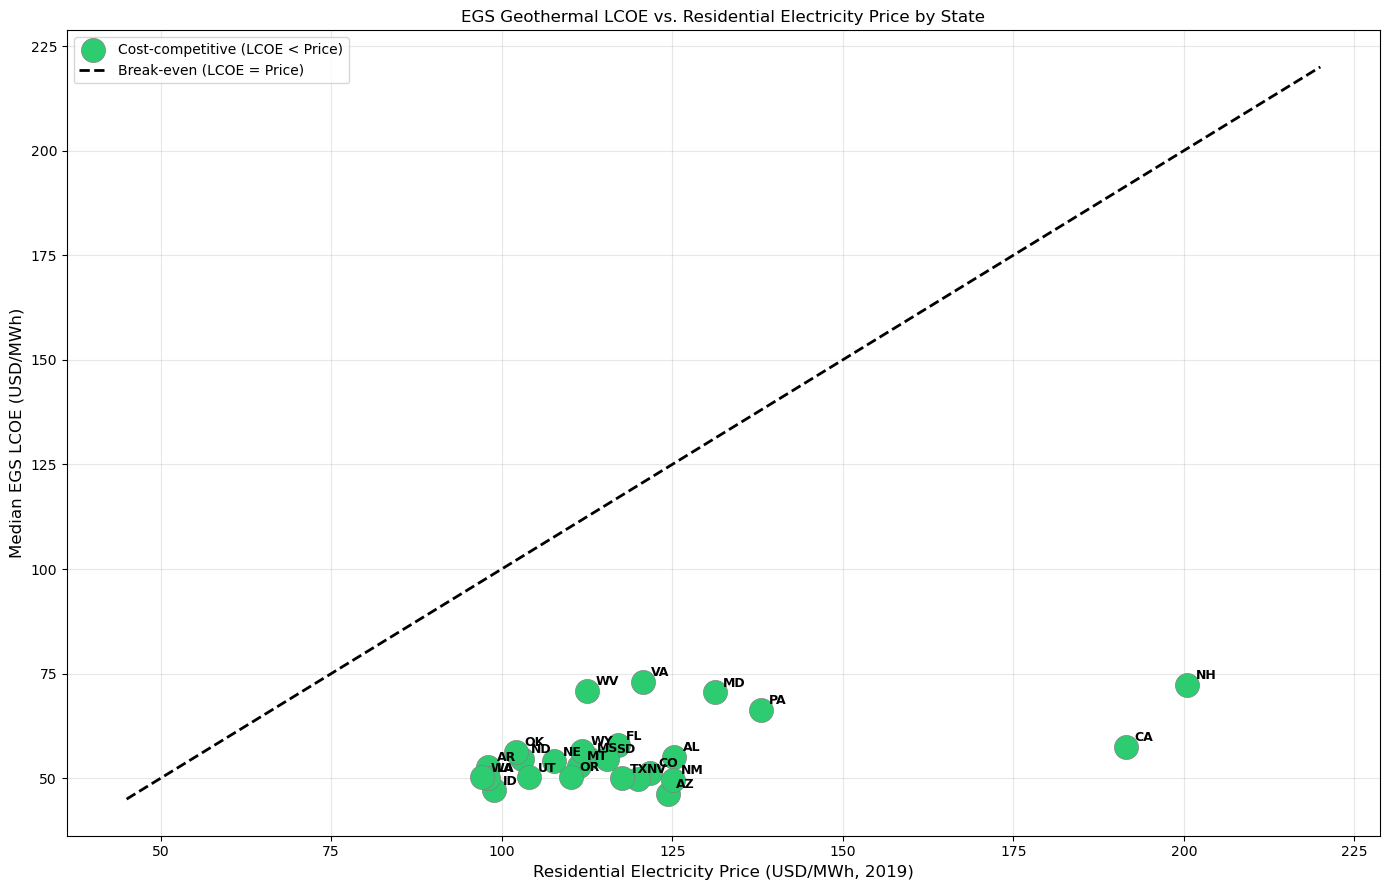

In [24]:
fig, ax = plt.subplots(figsize=(14, 9))

geo_data = state_geo_elec.dropna(subset=['median_lcoe'])

ax.scatter(geo_data['residential_usd_mwh'], geo_data['median_lcoe'],
           s=300, color='#2ecc71', edgecolors='gray', linewidths=0.5, 
           zorder=3, label='Cost-competitive (LCOE < Price)')

for _, row in geo_data.iterrows():
    ax.annotate(row['State'],
                (row['residential_usd_mwh'], row['median_lcoe']),
                xytext=(6, 4), textcoords='offset points',
                fontsize=9, fontweight='bold')

lims = [45, 220]
ax.plot(lims, lims, 'k--', linewidth=2, label='Break-even (LCOE = Price)')

ax.legend(fontsize=10)
ax.set_xlabel('Residential Electricity Price (USD/MWh, 2019)', fontsize=12)
ax.set_ylabel('Median EGS LCOE (USD/MWh)', fontsize=12)
ax.set_title('EGS Geothermal LCOE vs. Residential Electricity Price by State', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Figure 5: Price vs. Potential
This map overlays both variables: bubble size shows geothermal capacity and color shows electricity price. It directly visualizes the geographic mismatch which dispproves my initial hypothesis. 

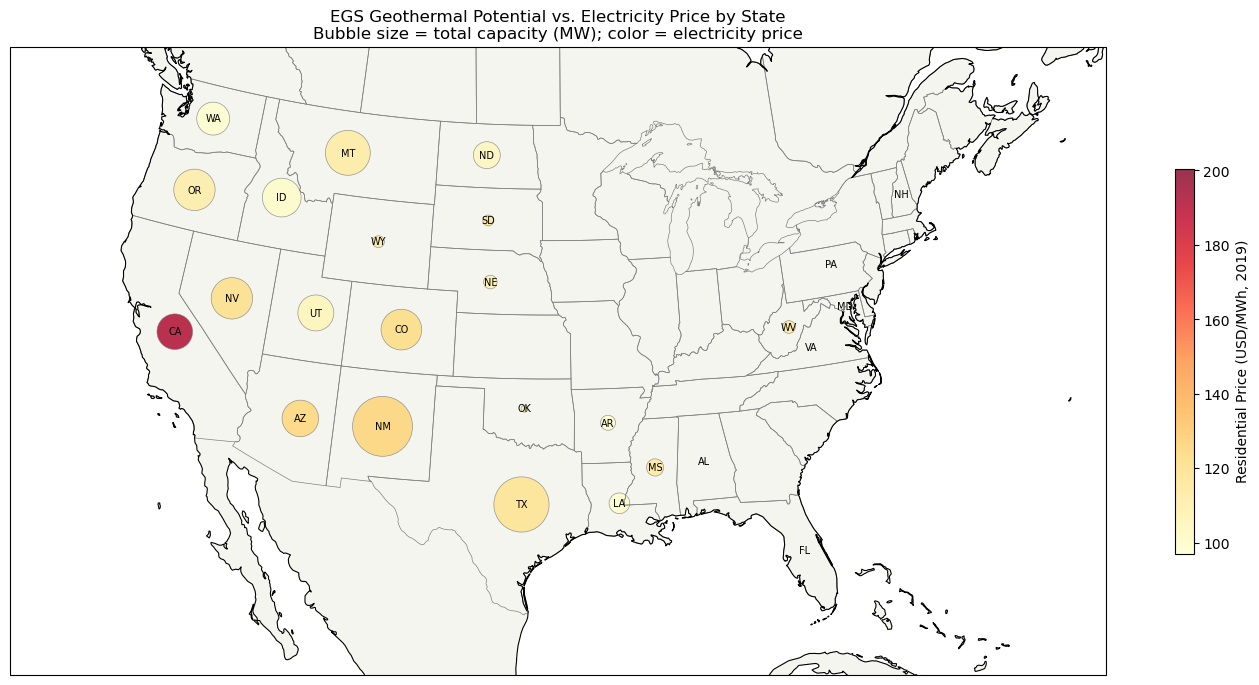

In [25]:
conus_geo = conus.dropna(subset=['total_capacity_mw'])

fig, ax = plt.subplots(figsize=(14, 8),
                       subplot_kw={'projection': ccrs.AlbersEqualArea(central_longitude=-96, central_latitude=37.5)})
ax.set_extent([-125, -66, 23, 50], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='#f5f5f0')

sc = ax.scatter(conus_geo['lon'], conus_geo['lat'],
                s=conus_geo['total_capacity_mw'] / 500,
                c=conus_geo['residential_usd_mwh'],
                cmap='YlOrRd', alpha=0.8,
                transform=ccrs.PlateCarree(), edgecolors='gray', linewidths=0.5)

for _, row in conus_geo.iterrows():
    ax.text(row['lon'], row['lat'], row['State'], fontsize=7,
            ha='center', va='center', transform=ccrs.PlateCarree())

plt.colorbar(sc, ax=ax, label='Residential Price (USD/MWh, 2019)', shrink=0.5)
ax.set_title('EGS Geothermal Potential vs. Electricity Price by State\nBubble size = total capacity (MW); color = electricity price', fontsize=12)
plt.tight_layout()
plt.show()

## Conclusions

My hypothesis is only partially supported. While all 26 states with EGS data at 6,500m have cost-competitive resources with an LCOE well below retail price. However,the most expensive states including Hawaii, Connecticut, Massachusetts, Rhode Island, New York have **no modeled geothermal potential** at this depth.

This geographic mismatch is interesting and not quite what I imagined to find: geothermal resources are concentrated in the West and Great Plains, while high electricity prices are concentrated in the Northeast. States like California, New Hampshire, and Pennsylvania are notable exceptions where both high prices and meaningful geothermal potential coincide.

**Limitations:** The 6,500m dataset covers only 26 states. LCOE also does not include transmission and distribution costs.